# Sleep Stage Classification Using Deep Learning
## Biomedical Signal Processing | Team 9

**Pipeline:**
1. Dataset Access & Loading: MESA Sleep Study (ECG @ 256Hz)
2. Signal Preprocessing: Notch filtering and Z-score normalization
3. Multi-Scale Feature Extraction: Extraction of raw waveforms and Context-Aware HRV features (5.5-minute windows)
4. Data Balancing: Implementation of WeightedRandomSampler to address severe class imbalance
5. Hybrid Architecture: Deep 1D-CNN for morphology + Bidirectional LSTM for temporal dependencies
6. Advanced Optimization: Focal Loss and Cosine Annealing Learning Rate scheduling
7. Performance Evaluation: Precision-Recall analysis and Confusion Matrix validation

**Reference Paper:** Zhang et al. (2023) – *A Multi-task Deep Learning Algorithm for Sleep Stage Scoring and Sleep Arousal Detection*  
**Dataset:** MESA Sleep Study (Multi-Ethnic Study of Atherosclerosis)  
**Signal used:** ECG only (256 Hz)  
**Classes:** Wake, Light (N1+N2), Deep (N3), REM

---
## Step 1 — Install extra dependency

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'neurokit2', '-q'])
print('neurokit2 ready')

neurokit2 ready


---
## Step 2 — Import Libraries

In [2]:
import os
import glob
import xml.etree.ElementTree as ET
import warnings
import re
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as scipy_signal
from scipy.interpolate import interp1d

import mne
mne.set_log_level('WARNING')

import neurokit2 as nk

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_fscore_support
)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from tqdm import tqdm

print('All libraries imported successfully!')

All libraries imported successfully!


---
## Step 3 — GPU Configuration & Reproducibility

In [3]:
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory // 1024**3} GB')
else:
    print('No GPU found – running on CPU (training will be slow).')

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
VRAM: 5 GB


---
## Step 4 — Global Config & Label Mapping

In [4]:
# Signal config
ECG_CHANNEL   = 'EKG'
SAMPLING_RATE = 256
EPOCH_SEC     = 30
EPOCH_SAMPLES = SAMPLING_RATE * EPOCH_SEC   # 7680 samples
NUM_CLASSES   = 4

# Each batch = BATCH_SIZE x CONTEXT_EPOCHS x 7680 x 4 bytes
BATCH_SIZE       = 8
CONTEXT_EPOCHS   = 11   
CONTEXT_HALF     = CONTEXT_EPOCHS // 2   # = 5
GRAD_ACCUM_STEPS = 4    # accumulate 4 steps -> effective batch size = 8x4 = 32

# HRV feature config
HRV_FEATURES = 8

# Training config 
NUM_EPOCHS    = 30
LEARNING_RATE = 3e-4
WARMUP_EPOCHS = 10

# Label mapping 
STAGE_MAP = {
    '0': 0, 'Wake': 0,
    '1': 1, '2': 1, 'N1': 1, 'N2': 1,
    '3': 2, '4': 2, 'N3': 2,
    '5': 3, 'REM': 3, 'R': 3,
}
CLASS_NAMES = ['Wake', 'Light (N1+N2)', 'Deep (N3)', 'REM']

print(f'Epoch length    : {EPOCH_SEC}s x {SAMPLING_RATE}Hz = {EPOCH_SAMPLES} samples')
print(f'Context window  : {CONTEXT_EPOCHS} epochs = {CONTEXT_EPOCHS * EPOCH_SEC / 60:.0f} minutes')
print(f'Batch size      : {BATCH_SIZE} (effective {BATCH_SIZE * GRAD_ACCUM_STEPS} with grad accumulation)')
est_mb = BATCH_SIZE * CONTEXT_EPOCHS * 7680 * 4 / 1024**2
print(f'Est. waveform tensor per batch: ~{est_mb:.0f} MB')


Epoch length    : 30s x 256Hz = 7680 samples
Context window  : 11 epochs = 6 minutes
Batch size      : 8 (effective 32 with grad accumulation)
Est. waveform tensor per batch: ~3 MB


---
## Step 5 — Dataset Access

In [5]:
DATA_DIR = r'D:\College\3rd Biomed\Projects & papers\3rd biomed\signals\Dataset'

edf_files = sorted(glob.glob(os.path.join(DATA_DIR, '**', '*.edf'), recursive=True))
xml_files = sorted(glob.glob(os.path.join(DATA_DIR, '**', '*nsrr.xml'), recursive=True))

print(f'Found {len(edf_files)} EDF files')
print(f'Found {len(xml_files)} XML annotation files')

Found 10 EDF files
Found 10 XML annotation files


---
## Step 6 — Exploring Dataset

In [6]:
import mne

raw = mne.io.read_raw_edf(r'D:\College\3rd Biomed\Projects & papers\3rd biomed\signals\Dataset\Signals\mesa-sleep-0001.edf')

print(raw.info)
print(raw.ch_names)

<Info | 8 non-empty values
 bads: []
 ch_names: EKG, EOG-L, EOG-R, EMG, EEG1, EEG2, EEG3, Pres, Flow, Snore, ...
 chs: 27 EEG
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: 1985-01-01 20:29:59 UTC
 nchan: 27
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: >
>
['EKG', 'EOG-L', 'EOG-R', 'EMG', 'EEG1', 'EEG2', 'EEG3', 'Pres', 'Flow', 'Snore', 'Thor', 'Abdo', 'Leg', 'Therm', 'Pos', 'EKG_Off', 'EOG-L_Off', 'EOG-R_Off', 'EMG_Off', 'EEG1_Off', 'EEG2_Off', 'EEG3_Off', 'Pleth', 'OxStatus', 'SpO2', 'HR', 'DHR']


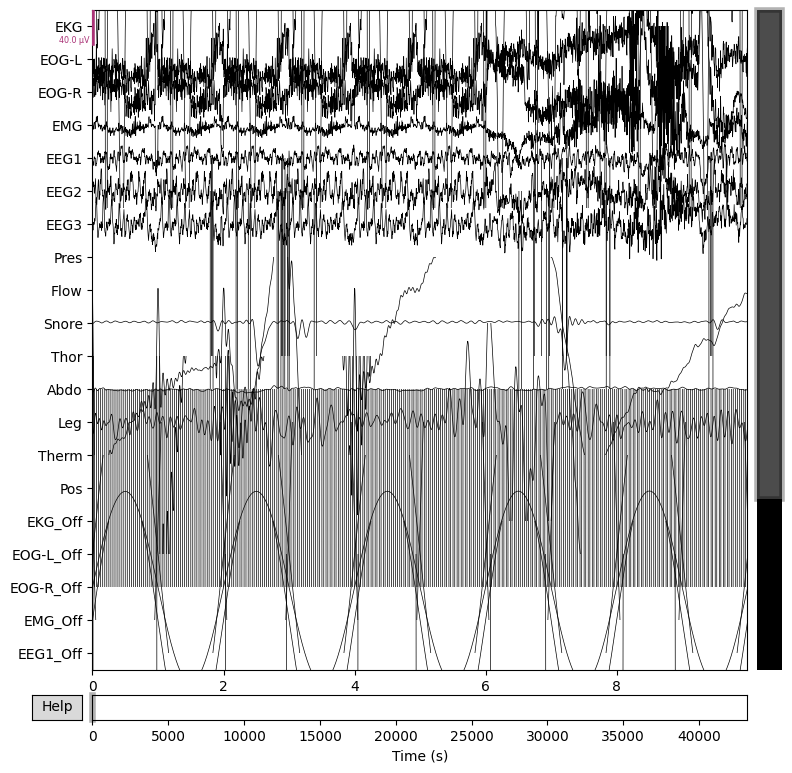

In [7]:
# Plotting the signals
raw = mne.io.read_raw_edf(r'D:\College\3rd Biomed\Projects & papers\3rd biomed\signals\Dataset\Signals\mesa-sleep-0001.edf', preload=True)
raw.plot();

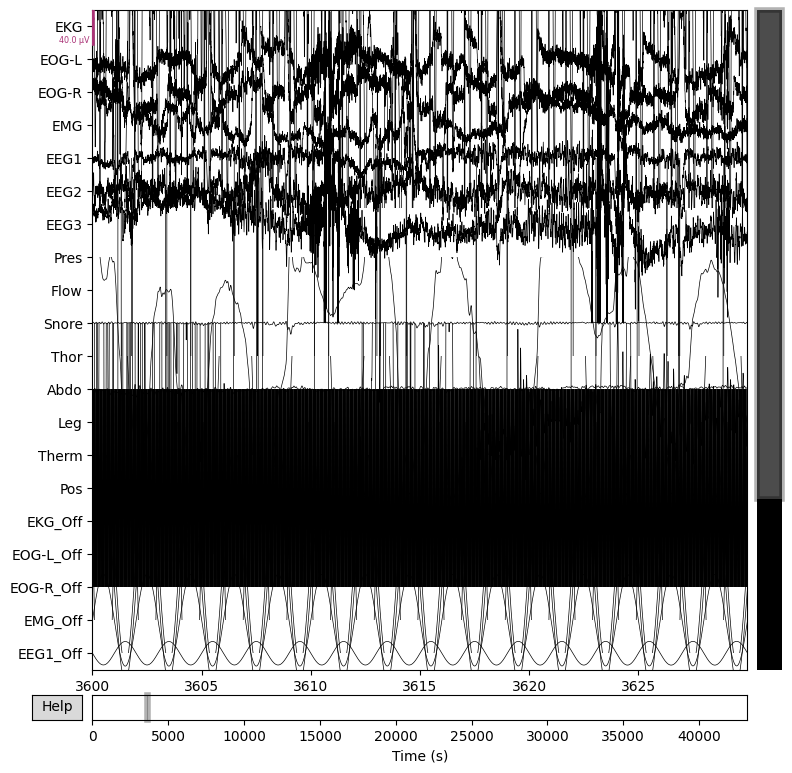

In [8]:
# Plotting only 30 secs 
raw.plot(start=3600, duration=30);

---
## Step 7 – Explore a Single Recording

In [9]:
# Inspect one EDF file
sample_edf = edf_files[0]
raw = mne.io.read_raw_edf(sample_edf, preload=False, verbose=False)

print('=== EDF File Info ===')
print(f'File: {os.path.basename(sample_edf)}')
print(f'Duration: {raw.times[-1]/3600:.2f} hours')
print(f'Sampling frequency: {raw.info["sfreq"]} Hz')
print(f'Number of channels: {len(raw.ch_names)}')
print(f'\nAll channels:')
for ch in raw.ch_names:
    print(f'  {ch}')

=== EDF File Info ===
File: mesa-sleep-0001.edf
Duration: 12.00 hours
Sampling frequency: 256.0 Hz
Number of channels: 27

All channels:
  EKG
  EOG-L
  EOG-R
  EMG
  EEG1
  EEG2
  EEG3
  Pres
  Flow
  Snore
  Thor
  Abdo
  Leg
  Therm
  Pos
  EKG_Off
  EOG-L_Off
  EOG-R_Off
  EMG_Off
  EEG1_Off
  EEG2_Off
  EEG3_Off
  Pleth
  OxStatus
  SpO2
  HR
  DHR


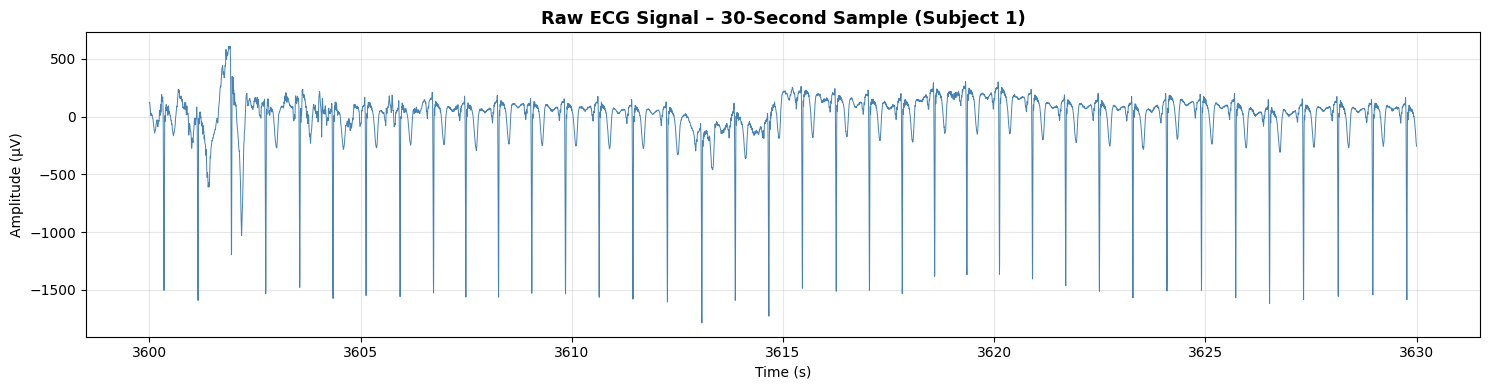

ECG shape: (1, 7680) → 1 channel × 7680 samples


In [10]:
# Plot a 30-second window of the EKG signal
raw_loaded = mne.io.read_raw_edf(sample_edf, preload=True, verbose=False)

# Extract 30 seconds starting at 1 hour into the recording
tmin, tmax = 3600, 3630
ecg_data, times = raw_loaded[ECG_CHANNEL, int(tmin * SAMPLING_RATE):int(tmax * SAMPLING_RATE)]

plt.figure(figsize=(15, 4))
plt.plot(np.linspace(tmin, tmax, ecg_data.shape[1]), ecg_data[0] * 1e6, color='steelblue', linewidth=0.7)
plt.title('Raw ECG Signal – 30-Second Sample (Subject 1)', fontsize=13, fontweight='bold')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude (µV)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'ECG shape: {ecg_data.shape} → 1 channel × {ecg_data.shape[1]} samples')

---
## Step 8 — Parse Sleep Stage Annotations

In [11]:
def parse_sleep_stages(xml_path):
    """
    Parse MESA NSRR XML annotation file.
    Returns array of integer labels (0=Wake, 1=Light, 2=Deep, 3=REM).
    """
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except Exception as e:
        print(f'  [ERROR] Cannot parse XML: {xml_path} – {e}')
        return None

    labels = []
    for event in root.iter('ScoredEvent'):
        event_type = event.findtext('EventType', default='')
        if 'Stage' not in event_type:
            continue
        stage_str = event.findtext('EventConcept', default='').strip()
        duration  = event.findtext('Duration', default='0')
        try:
            duration_sec = float(duration)
        except ValueError:
            continue
        n_epochs = max(1, int(round(duration_sec / EPOCH_SEC)))

        mapped = None
        pipe_match = re.search(r'\|(\d+)$', stage_str)
        if pipe_match:
            mapped = STAGE_MAP.get(pipe_match.group(1))
        if mapped is None:
            su = stage_str.upper()
            if 'WAKE' in su: mapped = 0
            elif 'REM' in su: mapped = 3
            elif 'STAGE 3' in su or 'STAGE 4' in su or 'N3' in su: mapped = 2
            elif 'STAGE 1' in su or 'STAGE 2' in su or 'N1' in su or 'N2' in su: mapped = 1
        if mapped is None:
            continue
        labels.extend([mapped] * n_epochs)

    if len(labels) == 0:
        return None
    return np.array(labels, dtype=np.int64)

# Quick test on first subject
sample_xml = xml_files[0]
sample_labels = parse_sleep_stages(sample_xml)

print(f'XML: {os.path.basename(sample_xml)}')
print(f'Total epochs: {len(sample_labels)}')
print(f'Duration: {len(sample_labels) * 30 / 3600:.2f} hours')
print(f'Stage distribution:')
for i, name in enumerate(CLASS_NAMES):
    count = np.sum(sample_labels == i)
    pct = count / len(sample_labels) * 100
    print(f'  {name}: {count} epochs ({pct:.1f}%)')
print('\nCheck stage_str values below:')

# Debug: print first few raw EventConcept strings
import xml.etree.ElementTree as ET2
tree2 = ET2.parse(sample_xml)
seen = set()
for ev in tree2.getroot().iter('ScoredEvent'):
    et = ev.findtext('EventType', '')
    ec = ev.findtext('EventConcept', '')
    if 'Stage' in et and ec not in seen:
        print(f'  EventConcept raw: "{ec}"')
        seen.add(ec)
        if len(seen) >= 8:
            break

XML: mesa-sleep-0001-nsrr.xml
Total epochs: 1439
Duration: 11.99 hours
Stage distribution:
  Wake: 752 epochs (52.3%)
  Light (N1+N2): 590 epochs (41.0%)
  Deep (N3): 19 epochs (1.3%)
  REM: 78 epochs (5.4%)

Check stage_str values below:
  EventConcept raw: "Wake|0"
  EventConcept raw: "Stage 1 sleep|1"
  EventConcept raw: "Stage 2 sleep|2"
  EventConcept raw: "REM sleep|5"
  EventConcept raw: "Stage 3 sleep|3"


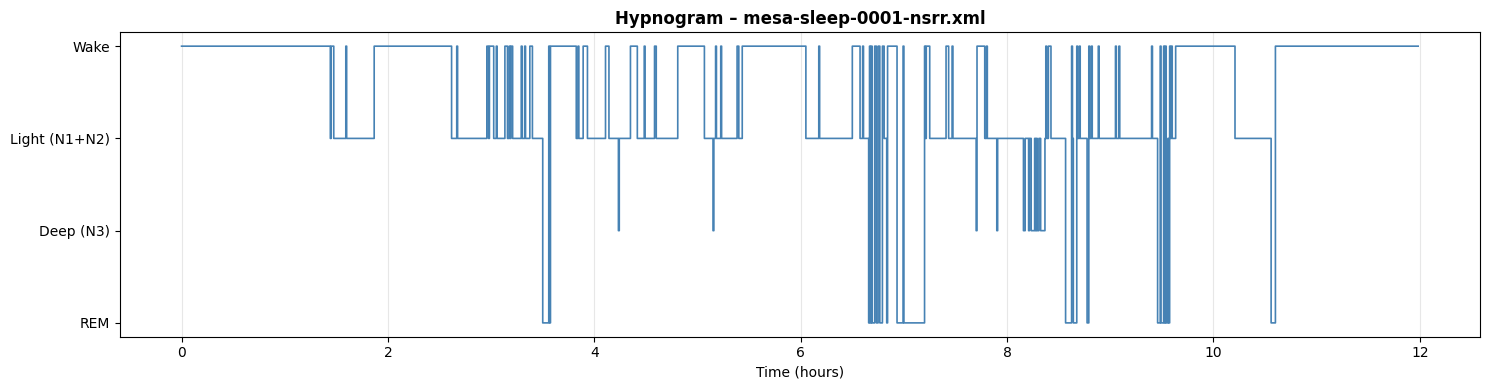

In [12]:
# Visualize hypnogram (sleep stage over the night)
plt.figure(figsize=(15, 4))
time_hours = np.arange(len(sample_labels)) * 30 / 3600
plt.step(time_hours, sample_labels, where='post', color='steelblue', linewidth=1.2)
plt.yticks([0, 1, 2, 3], CLASS_NAMES)
plt.xlabel('Time (hours)')
plt.title(f'Hypnogram – {os.path.basename(sample_xml)}', fontsize=12, fontweight='bold')
plt.grid(True, axis='x', alpha=0.3)
plt.gca().invert_yaxis()   # Wake on top, Deep on bottom
plt.tight_layout()
plt.show()

---
## Step 9 — Signal Preprocessing

In [13]:
def bandpass_filter(signal_1d, lowcut=0.5, highcut=40.0, fs=256, order=4):
    nyq  = fs / 2.0
    low  = lowcut / nyq
    high = min(highcut / nyq, 0.99)
    b, a = scipy_signal.butter(order, [low, high], btype='bandpass')
    return scipy_signal.filtfilt(b, a, signal_1d)


def notch_filter(signal_1d, notch_freq=60.0, fs=256, quality=30):
    b, a = scipy_signal.iirnotch(notch_freq / (fs / 2.0), quality)
    return scipy_signal.filtfilt(b, a, signal_1d)


def normalize_epoch(epoch_1d):
    std = np.std(epoch_1d)
    if std < 1e-8:
        return np.zeros_like(epoch_1d)
    return (epoch_1d - np.mean(epoch_1d)) / std


def preprocess_ecg(raw_ecg_1d, fs=256, notch_freq=60.0):
    """Bandpass 0.5–40 Hz + Notch 60 Hz (MESA is US data)."""
    ecg = bandpass_filter(raw_ecg_1d, lowcut=0.5, highcut=40.0, fs=fs)
    ecg = notch_filter(ecg, notch_freq=notch_freq, fs=fs)
    return ecg


print('Preprocessing functions defined.')

Preprocessing functions defined.


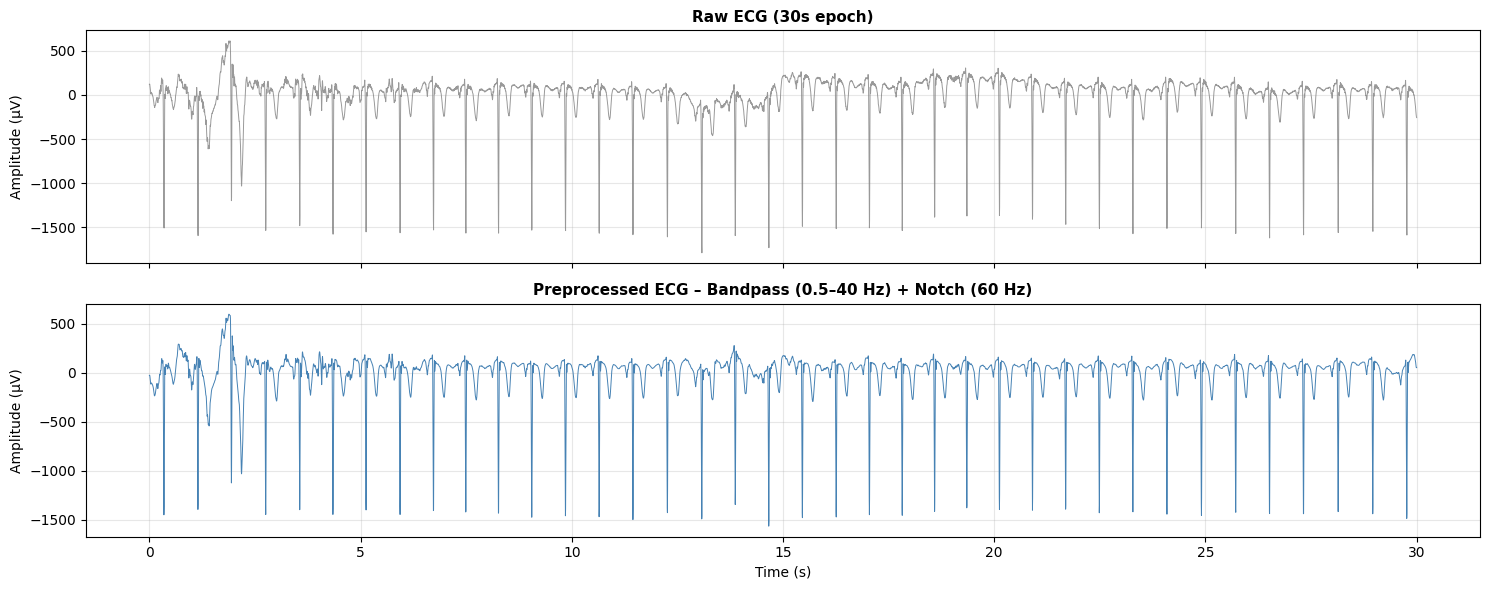

In [14]:
# Visualize preprocessing effect on the sample epoch 
raw_ecg_sample   = ecg_data[0] * 1e6
clean_ecg_sample = preprocess_ecg(raw_ecg_sample, fs=SAMPLING_RATE, notch_freq=60.0)

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
t = np.linspace(0, EPOCH_SEC, EPOCH_SAMPLES)

axes[0].plot(t, raw_ecg_sample,   color='gray',      linewidth=0.7, alpha=0.8)
axes[0].set_title('Raw ECG (30s epoch)',             fontsize=11, fontweight='bold')
axes[0].set_ylabel('Amplitude (µV)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, clean_ecg_sample, color='steelblue', linewidth=0.7)
axes[1].set_title('Preprocessed ECG – Bandpass (0.5–40 Hz) + Notch (60 Hz)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Amplitude (µV)')
axes[1].set_xlabel('Time (s)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 10 — HRV Feature Extraction

Heart Rate Variability features capture autonomic nervous system activity that strongly differentiates sleep stages. These complement the raw waveform features from the CNN.

In [15]:
def extract_hrv_features(epoch_1d, fs=256):
    """
    Extract 8 HRV features from a 30-second ECG epoch.

    Time-domain:
      - mean_rr    : mean R-R interval (ms)
      - sdnn       : std of R-R intervals (ms) — overall HRV
      - rmssd      : root mean square of successive differences — short-term HRV
      - nn50_ratio : fraction of successive differences > 50 ms
      - mean_hr    : mean heart rate (bpm)

    Frequency-domain (Lomb-Scargle on 30s, so VLF excluded):
      - lf_power   : low-frequency power (0.04–0.15 Hz) — sympathetic + parasympathetic
      - hf_power   : high-frequency power (0.15–0.40 Hz) — parasympathetic (sleep marker)
      - lf_hf      : LF/HF ratio — autonomic balance

    Returns np.array of shape (8,), all NaN-replaced with 0.
    """
    try:
        # Detect R-peaks using Pan-Tompkins algorithm via neurokit2
        _, rpeaks_info = nk.ecg_peaks(epoch_1d, sampling_rate=fs, method='pantompkins1985')
        rpeaks = rpeaks_info['ECG_R_Peaks']

        if len(rpeaks) < 4:    # need at least 4 beats for meaningful HRV
            return np.zeros(HRV_FEATURES, dtype=np.float32)

        # R-R intervals in milliseconds
        rr_ms = np.diff(rpeaks) / fs * 1000.0

        # Time-domain 
        mean_rr    = np.mean(rr_ms)
        sdnn       = np.std(rr_ms)
        diff_rr    = np.diff(rr_ms)
        rmssd      = np.sqrt(np.mean(diff_rr ** 2)) if len(diff_rr) > 0 else 0.0
        nn50_ratio = np.sum(np.abs(diff_rr) > 50) / len(diff_rr) if len(diff_rr) > 0 else 0.0
        mean_hr    = 60000.0 / mean_rr if mean_rr > 0 else 0.0

        # Frequency-domain (Lomb-Scargle) 
        # Peak times in seconds
        t_peaks = rpeaks[1:] / fs   # times of each R-R interval endpoint
        if len(t_peaks) >= 4:
            freqs = np.linspace(0.04, 0.40, 200)
            pgram = scipy_signal.lombscargle(t_peaks, rr_ms - rr_ms.mean(),
                                              freqs * 2 * np.pi, normalize=True)
            lf_mask = (freqs >= 0.04) & (freqs < 0.15)
            hf_mask = (freqs >= 0.15) & (freqs < 0.40)
            lf_power = np.trapezoid(pgram[lf_mask], freqs[lf_mask]) if lf_mask.sum() > 1 else 0.0
            hf_power = np.trapezoid(pgram[hf_mask], freqs[hf_mask]) if hf_mask.sum() > 1 else 0.0
            lf_hf    = lf_power / (hf_power + 1e-8)
        else:
            lf_power = hf_power = lf_hf = 0.0

        features = np.array([
            mean_rr, sdnn, rmssd, nn50_ratio, mean_hr,
            lf_power, hf_power, lf_hf
        ], dtype=np.float32)

        # Replace any NaN/Inf with 0
        features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
        return features

    except Exception as e:
        return np.zeros(HRV_FEATURES, dtype=np.float32)


print(f'HRV feature extractor defined. Output size: {HRV_FEATURES} features per epoch.')

HRV feature extractor defined. Output size: 8 features per epoch.


---
## Step 11 — Per-Subject Epoch Extraction

In [16]:
def extract_epochs_from_subject(edf_path, xml_path, fs=256, epoch_sec=30,
                                 ecg_channel='EKG', notch_freq=60.0):
    """
    Load one subject. Returns:
      epochs   – np.array (N, epoch_samples) float32  — normalized raw waveforms
      hrv_feat – np.array (N, HRV_FEATURES)  float32  — HRV features per epoch (5.5 min context)
      labels   – np.array (N,)               int64
    """
    epoch_samples = fs * epoch_sec

    try:
        raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
    except Exception as e:
        print(f'  [ERROR] EDF load failed: {e}')
        return None, None, None

    # Find ECG channel
    if ecg_channel not in raw.ch_names:
        aliases = ['EKG', 'ECG', 'ECG1', 'EKG1']
        found = [a for a in aliases if a in raw.ch_names]
        if not found:
            return None, None, None
        ecg_channel = found[0]

    ecg_raw, _ = raw[ecg_channel]
    ecg_raw = ecg_raw[0] * 1e6   # µV
    ecg_clean = preprocess_ecg(ecg_raw, fs=fs, notch_freq=notch_freq)

    labels_all = parse_sleep_stages(xml_path)
    if labels_all is None or len(labels_all) == 0:
        return None, None, None

    n_epochs = min(len(ecg_clean) // epoch_samples, len(labels_all))

    epochs_list   = []
    hrv_list      = []
    labels_list   = []

    for i in range(n_epochs):
        start = i * epoch_samples
        end   = start + epoch_samples
        epoch = ecg_clean[start:end]
        label = labels_all[i]

        std = np.std(epoch)
        if std < 1e-6 or std > 5000:
            continue
            
        # Extract HRV using a 5.5 minute window around the current epoch (11 epochs)
        hrv_start = max(0, (i - 5) * epoch_samples)
        hrv_end = min(len(ecg_clean), (i + 6) * epoch_samples)
        hrv_window = ecg_clean[hrv_start:hrv_end]
        
        hrv = extract_hrv_features(hrv_window, fs=fs)
        epoch_norm = normalize_epoch(epoch)

        epochs_list.append(epoch_norm.astype(np.float32))
        hrv_list.append(hrv)
        labels_list.append(label)

    if len(epochs_list) == 0:
        return None, None, None

    return (
        np.array(epochs_list,  dtype=np.float32),
        np.array(hrv_list,     dtype=np.float32),
        np.array(labels_list,  dtype=np.int64)
    )

print('Epoch extraction function defined.')

Epoch extraction function defined.


---
## Step 12 — Load All Subjects

In [17]:
def get_subject_id(path):
    base  = os.path.basename(path)
    parts = base.replace('.edf', '').replace('-nsrr.xml', '').split('-')
    return parts[-1]

edf_dict   = {get_subject_id(f): f for f in edf_files}
xml_dict   = {get_subject_id(f): f for f in xml_files}
common_ids = sorted(set(edf_dict.keys()) & set(xml_dict.keys()))

print(f'Subjects with both EDF and XML: {len(common_ids)}')

Subjects with both EDF and XML: 10


In [18]:
# Set MAX_SUBJECTS = 10 for a quick test run, None for full dataset
MAX_SUBJECTS = None

subject_list = common_ids[:MAX_SUBJECTS] if MAX_SUBJECTS else common_ids

all_epochs      = []   # list of (N_i, 7680) arrays per subject
all_hrv         = []   # list of (N_i, 8) arrays per subject
all_labels      = []   # list of (N_i,) arrays per subject
all_subject_ids = []   # flat list of subject id strings

# We store per-subject arrays separately so we can build context windows correctly
# (context windows must not cross subject boundaries)
subject_epochs_list = []   # list of per-subject epoch arrays
subject_hrv_list    = []   # list of per-subject hrv arrays
subject_labels_list = []   # list of per-subject label arrays
subject_id_list     = []   # list of subject id strings (one per subject)

print(f'Loading {len(subject_list)} subjects...\n')

for sid in tqdm(subject_list, desc='Processing subjects'):
    epochs, hrv, labels = extract_epochs_from_subject(
        edf_dict[sid], xml_dict[sid],
        fs=SAMPLING_RATE, epoch_sec=EPOCH_SEC,
        ecg_channel=ECG_CHANNEL, notch_freq=60.0
    )
    if epochs is None:
        continue

    subject_epochs_list.append(epochs)
    subject_hrv_list.append(hrv)
    subject_labels_list.append(labels)
    subject_id_list.append(sid)

print(f'\nSuccessfully loaded: {len(subject_id_list)} subjects')

# Class distribution across all data
all_labs_flat = np.concatenate(subject_labels_list)
print(f'Total epochs: {len(all_labs_flat)}')
for i, name in enumerate(CLASS_NAMES):
    c = np.sum(all_labs_flat == i)
    print(f'  [{i}] {name}: {c} ({c/len(all_labs_flat)*100:.1f}%)')

Loading 10 subjects...



Processing subjects: 100%|██████████| 10/10 [06:38<00:00, 39.82s/it]


Successfully loaded: 10 subjects
Total epochs: 12758
  [0] Wake: 5569 (43.7%)
  [1] Light (N1+N2): 5059 (39.7%)
  [2] Deep (N3): 869 (6.8%)
  [3] REM: 1261 (9.9%)


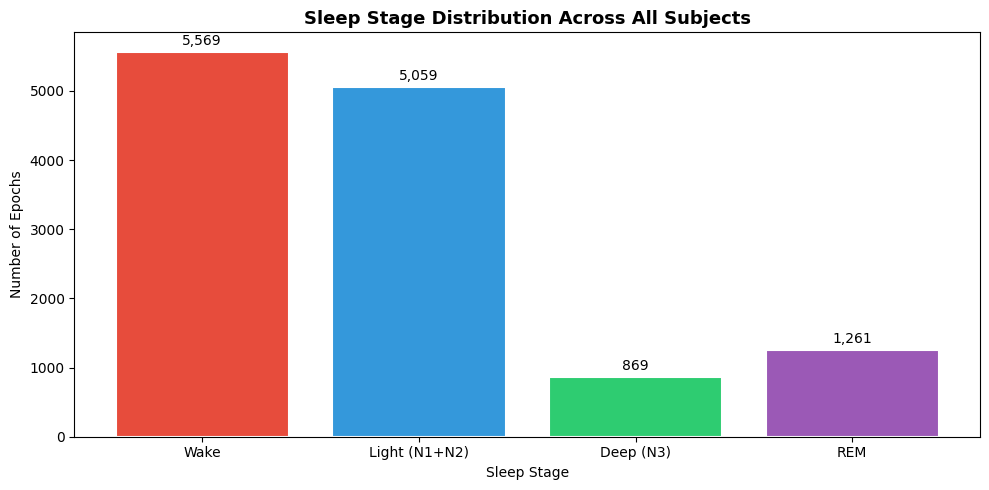

Note: Class imbalance is expected (N2/Light dominates in normal sleep).


In [19]:
# ─── Visualize class distribution ────────────────────────────────
class_counts = [np.sum(all_labs_flat == i) for i in range(NUM_CLASSES)]
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

plt.figure(figsize=(10, 5))
bars = plt.bar(CLASS_NAMES, class_counts, color=colors, edgecolor='white', linewidth=1.5)
plt.title('Sleep Stage Distribution Across All Subjects', fontsize=13, fontweight='bold')
plt.ylabel('Number of Epochs')
plt.xlabel('Sleep Stage')
for bar, count in zip(bars, class_counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{count:,}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()
print('Note: Class imbalance is expected (N2/Light dominates in normal sleep).')

---
## Step 13 — HRV Feature Normalization

HRV features have very different scales (RR intervals in 600–1000 ms range,
frequency powers near 0). We normalize them using training-set statistics only
(to avoid data leakage).

In [20]:
# Subject-independent split FIRST, then compute HRV stats on train only
np.random.seed(SEED)
unique_subjects = np.array(subject_id_list)
np.random.shuffle(unique_subjects)

n_total = len(unique_subjects)
n_test  = int(n_total * 0.10)
n_val   = int(n_total * 0.20)
n_train = n_total - n_test - n_val

test_subjects  = set(unique_subjects[:n_test])
val_subjects   = set(unique_subjects[n_test:n_test + n_val])
train_subjects = set(unique_subjects[n_test + n_val:])

print(f'Subjects → Train: {n_train} | Val: {n_val} | Test: {n_test}')

# Collect training HRV arrays to compute normalization stats
train_hrv_all = []
for sid, hrv in zip(subject_id_list, subject_hrv_list):
    if sid in train_subjects:
        train_hrv_all.append(hrv)

train_hrv_concat = np.concatenate(train_hrv_all, axis=0)
hrv_mean = train_hrv_concat.mean(axis=0)   # shape (8,)
hrv_std  = train_hrv_concat.std(axis=0) + 1e-8

print(f'HRV normalization computed from {len(train_hrv_concat)} training epochs')
feature_names = ['mean_rr','sdnn','rmssd','nn50_ratio','mean_hr','lf_power','hf_power','lf_hf']
for name, m, s in zip(feature_names, hrv_mean, hrv_std):
    print(f'  {name:12s}: mean={m:.3f}  std={s:.3f}')

Subjects → Train: 7 | Val: 2 | Test: 1
HRV normalization computed from 8561 training epochs
  mean_rr     : mean=851.024  std=472.432
  sdnn        : mean=304.684  std=1559.521
  rmssd       : mean=373.328  std=2052.267
  nn50_ratio  : mean=0.362  std=0.138
  mean_hr     : mean=81.474  std=36.385
  lf_power    : mean=0.001  std=0.001
  hf_power    : mean=0.001  std=0.002
  lf_hf       : mean=0.563  std=0.459


---
## Step 14 — Build Context-Window Dataset

Instead of classifying each epoch alone, we stack CONTEXT_EPOCHS=21 consecutive
epochs and classify the CENTER one.

In [21]:
def build_context_windows(subject_epochs_list, subject_hrv_list,
                           subject_labels_list, subject_id_list,
                           subject_set, hrv_mean, hrv_std,
                           context_half=None):
    if context_half is None:
        context_half = CONTEXT_HALF
    X_waveform, X_hrv, Y, subjects = [], [], [], []

    for sid, epochs, hrv, labels in zip(subject_id_list, subject_epochs_list,
                                         subject_hrv_list, subject_labels_list):
        if sid not in subject_set:
            continue
        n = len(labels)
        hrv_norm = (hrv - hrv_mean) / hrv_std
        for i in range(n):
            indices = [int(np.clip(i + delta, 0, n - 1))
                       for delta in range(-context_half, context_half + 1)]
            X_waveform.append(epochs[indices])
            X_hrv.append(hrv_norm[indices])
            Y.append(labels[i])
            subjects.append(sid)

    return (
        np.array(X_waveform, dtype=np.float32),
        np.array(X_hrv,      dtype=np.float32),
        np.array(Y,          dtype=np.int64),
        np.array(subjects)
    )


print('Building context windows for each split...')

X_wav_train, X_hrv_train, y_train, _ = build_context_windows(
    subject_epochs_list, subject_hrv_list, subject_labels_list, subject_id_list,
    train_subjects, hrv_mean, hrv_std
)
X_wav_val, X_hrv_val, y_val, _ = build_context_windows(
    subject_epochs_list, subject_hrv_list, subject_labels_list, subject_id_list,
    val_subjects, hrv_mean, hrv_std
)
X_wav_test, X_hrv_test, y_test, test_sids = build_context_windows(
    subject_epochs_list, subject_hrv_list, subject_labels_list, subject_id_list,
    test_subjects, hrv_mean, hrv_std
)

print(f'Waveform shape : {X_wav_train.shape}  (N, context_epochs, epoch_samples)')
print(f'HRV shape      : {X_hrv_train.shape}   (N, context_epochs, hrv_features)')
print(f'Epochs  -> Train: {len(y_train):,} | Val: {len(y_val):,} | Test: {len(y_test):,}')


Building context windows for each split...
Waveform shape : (8561, 11, 7680)  (N, context_epochs, epoch_samples)
HRV shape      : (8561, 11, 8)   (N, context_epochs, hrv_features)
Epochs  -> Train: 8,561 | Val: 2,998 | Test: 1,199


---
## Step 15 — Class Weights

In [22]:
class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

print('Class weights (to correct imbalance):')
for i, (name, w) in enumerate(zip(CLASS_NAMES, class_weights_np)):
    print(f'  [{i}] {name}: {w:.3f}')

Class weights (to correct imbalance):
  [0] Wake: 0.542
  [1] Light (N1+N2): 0.616
  [2] Deep (N3): 5.012
  [3] REM: 3.002


---
## Step 16 — PyTorch Dataset with Augmentation

In [23]:
class SleepECGDataset(Dataset):
    def __init__(self, X_wav, X_hrv, labels, augment=False):
        self.X_wav   = X_wav      
        self.X_hrv   = X_hrv      
        self.labels  = labels
        self.augment = augment
        self.center  = X_wav.shape[1] // 2 

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        wav = self.X_wav[idx].copy()   
        hrv = self.X_hrv[idx].copy()   
        label = self.labels[idx]

        if self.augment:
            if np.random.rand() < 0.5:
                wav += np.random.default_rng().standard_normal(wav.shape, dtype=np.float32) * 0.02
            if np.random.rand() < 0.5:
                scale = np.random.uniform(0.90, 1.10)
                wav *= scale
            if np.random.rand() < 0.3:
                shift = np.random.randint(1, 128)
                wav[self.center] = np.roll(wav[self.center], shift)

        wav_tensor = torch.FloatTensor(wav).unsqueeze(1)
        hrv_tensor = torch.FloatTensor(hrv[self.center])
        label_tensor = torch.tensor(label, dtype=torch.long)

        return wav_tensor, hrv_tensor, label_tensor

train_dataset = SleepECGDataset(X_wav_train, X_hrv_train, y_train, augment=True)
val_dataset   = SleepECGDataset(X_wav_val,   X_hrv_val,   y_val,   augment=False)
test_dataset  = SleepECGDataset(X_wav_test,  X_hrv_test,  y_test,  augment=False)

# Weighted Random Sampler to fix class imbalance
class_sample_counts = np.bincount(y_train)
# Add a small epsilon to avoid divide-by-zero just in case
weights = 1.0 / (class_sample_counts + 1e-8) 
sample_weights = weights[y_train]

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

# shuffle must be False when using a sampler
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=0, pin_memory=False, drop_last=True)

val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}')

Train batches: 1070 | Val: 375 | Test: 150


---
## Step 17 — Model Architecture

In [24]:
from torch.utils.checkpoint import checkpoint

class ConvBlock(nn.Module):
    """
    Residual conv block with 1x1 projection shortcut (proper ResNet style).
    Memory-optimized: max 128 channels (was 256).
    """
    def __init__(self, in_ch, out_ch, kernel_size, pool_size=2):
        super().__init__()
        padding = kernel_size // 2
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size,
                      padding=padding, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.GELU(),
            nn.MaxPool1d(kernel_size=pool_size),
        )
        self.shortcut = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm1d(out_ch),
            nn.AvgPool1d(kernel_size=pool_size)
        )

    def forward(self, x):
        return self.conv(x) + self.shortcut(x)


class EpochCNN(nn.Module):
    """
    Slim CNN — max 128 channels instead of 256.
    Cutting channels from 256->128 reduces conv memory by ~4x.
    Output: 128-dim vector per epoch (was 256).
    """
    def __init__(self, cnn_out_dim=128):
        super().__init__()
        self.cnn = nn.Sequential(
            ConvBlock(1,   32,  kernel_size=7, pool_size=2),
            ConvBlock(32,  64,  kernel_size=5, pool_size=2),
            ConvBlock(64,  128, kernel_size=5, pool_size=2),
            ConvBlock(128, 128, kernel_size=3, pool_size=2),
            ConvBlock(128, 128, kernel_size=3, pool_size=2),
        )
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.out_dim = cnn_out_dim

    def forward(self, x):
        return self.gap(self.cnn(x)).squeeze(-1)   # (B, 128)


class SleepStagerV2(nn.Module):
    """
    Memory-optimized architecture for 6 GB GPU.
    Key changes:
      - CNN channels: 256 -> 128  (4x less conv activation memory)
      - LSTM hidden:  256 -> 128  (4x less LSTM state memory)
      - Context epochs: 21 -> 11 (set in CONTEXT_EPOCHS config)
      - Gradient checkpointing on CNN loop: recomputes activations during
        backward pass instead of storing all 11 epoch CNN feature maps

    This keeps all the important architectural improvements (residual
    connections, BiLSTM, attention, HRV fusion) while fitting in 6 GB.
    """
    def __init__(self, num_classes=4, context_epochs=CONTEXT_EPOCHS,
                 lstm_hidden=128, lstm_layers=2,
                 hrv_features=HRV_FEATURES, dropout=0.3):
        super().__init__()
        self.context_epochs = context_epochs
        self.epoch_cnn = EpochCNN(cnn_out_dim=128)

        self.lstm = nn.LSTM(
            input_size=128,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0
        )

        lstm_out_dim = lstm_hidden * 2   # 256

        self.attention = nn.Sequential(
            nn.Linear(lstm_out_dim, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

        self.hrv_proj = nn.Sequential(
            nn.Linear(hrv_features, 32),
            nn.LayerNorm(32),
            nn.GELU()
        )

        classifier_in = lstm_out_dim + 32   # 288
        self.classifier = nn.Sequential(
            nn.Linear(classifier_in, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.LayerNorm(64),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(64, num_classes)
        )

    def _cnn_step(self, epoch_slice):
        return self.epoch_cnn(epoch_slice)

    def forward(self, wav, hrv):
        B, T, C, L = wav.shape

        # Gradient checkpointing: process each of the T epochs individually.
        # During training, activations are NOT stored — they're recomputed
        # in the backward pass. This saves ~T x (CNN activation size) of VRAM.
        cnn_feats = []
        for t in range(T):
            epoch_t = wav[:, t, :, :]          # (B, 1, 7680)
            if self.training:
                feat = torch.utils.checkpoint.checkpoint(
                    self._cnn_step, epoch_t, use_reentrant=False
                )
            else:
                feat = self.epoch_cnn(epoch_t)  # no checkpointing at inference
            cnn_feats.append(feat)

        cnn_seq  = torch.stack(cnn_feats, dim=1)      # (B, T, 128)
        lstm_out, _ = self.lstm(cnn_seq)               # (B, T, 256)

        attn_w  = torch.softmax(self.attention(lstm_out), dim=1)  # (B, T, 1)
        context = (lstm_out * attn_w).sum(dim=1)       # (B, 256)

        hrv_feat = self.hrv_proj(hrv)                  # (B, 32)
        fused    = torch.cat([context, hrv_feat], dim=1)   # (B, 288)
        return self.classifier(fused)                  # (B, 4)


# Clear any previous model before allocating new one
import gc
try:
    del model
    torch.cuda.empty_cache()
    gc.collect()
except NameError:
    pass

model = SleepStagerV2(
    num_classes=NUM_CLASSES,
    context_epochs=CONTEXT_EPOCHS,
    lstm_hidden=128,
    lstm_layers=2,
    hrv_features=HRV_FEATURES,
    dropout=0.1
).to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model            : SleepStagerV2 (memory-optimized)')
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable_params:,}')

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    free, total_mem = torch.cuda.mem_get_info()
    print(f'GPU free before forward: {free/1024**3:.2f} GB / {total_mem/1024**3:.2f} GB')

with torch.no_grad():
    dummy_wav = torch.randn(2, CONTEXT_EPOCHS, 1, EPOCH_SAMPLES).to(device)
    dummy_hrv = torch.randn(2, HRV_FEATURES).to(device)
    dummy_out = model(dummy_wav, dummy_hrv)
    print(f'Forward pass OK  : wav{list(dummy_wav.shape)} -> {list(dummy_out.shape)}')

if torch.cuda.is_available():
    peak = torch.cuda.max_memory_allocated() / 1024**3
    print(f'Peak GPU memory (forward only): {peak:.2f} GB')
    torch.cuda.reset_peak_memory_stats()


Model            : SleepStagerV2 (memory-optimized)
Total params     : 908,645
Trainable params : 908,645
GPU free before forward: 5.00 GB / 6.00 GB
Forward pass OK  : wav[2, 11, 1, 7680] -> [2, 4]
Peak GPU memory (forward only): 0.04 GB


---
## Step 18 — Training Configuration

In [25]:
# Focal Loss helps the model focus on hard-to-classify examples (Deep/REM)
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma * ce_loss).mean()
        return focal_loss

# Because we are using the WeightedRandomSampler, the batches are already balanced. 
# We don't need class weights in the loss anymore.
criterion = FocalLoss(gamma=2.0)

optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=2e-4,    
    betas=(0.9, 0.999)
)

# Cosine Annealing scheduler to help the model escape local minima
scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=1, eta_min=1e-6)

print('Training configuration:')
print(f'  Loss         : FocalLoss (gamma=2.0)')
print(f'  Optimizer    : AdamW (lr={LEARNING_RATE}, weight_decay=2e-4)')
print(f'  Scheduler    : CosineAnnealingWarmRestarts')
print(f'  Epochs       : {NUM_EPOCHS}')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  Grad clip    : 1.0')

Training configuration:
  Loss         : FocalLoss (gamma=2.0)
  Optimizer    : AdamW (lr=0.0003, weight_decay=2e-4)
  Scheduler    : CosineAnnealingWarmRestarts
  Epochs       : 30
  Batch size   : 8
  Grad clip    : 1.0


---
## Step 19 — Mixup Augmentation

Mixup interpolates between pairs of training samples, smoothing the decision boundary and acting as a strong regularizer.

In [26]:
def mixup_batch(wav, hrv, labels, alpha=0.2, num_classes=4):
    """
    Apply Mixup augmentation to a batch.
    Returns mixed (wav, hrv) and soft labels for both samples.

    We use soft labels directly (no hard labels after mixing).
    The loss is computed as: λ * CE(pred, y_a) + (1-λ) * CE(pred, y_b)
    """
    if alpha <= 0:
        one_hot = F.one_hot(labels, num_classes).float()
        return wav, hrv, one_hot, one_hot, 1.0

    lam = np.random.beta(alpha, alpha)
    batch_size = wav.size(0)
    perm = torch.randperm(batch_size, device=wav.device)

    mixed_wav = lam * wav + (1 - lam) * wav[perm]
    mixed_hrv = lam * hrv + (1 - lam) * hrv[perm]

    y_a = F.one_hot(labels,      num_classes).float()
    y_b = F.one_hot(labels[perm], num_classes).float()

    return mixed_wav, mixed_hrv, y_a, y_b, lam


def mixup_criterion(criterion_fn, logits, y_a, y_b, lam):
    """Compute mixed loss. Works with soft targets."""
    # Convert soft labels to class indices for CrossEntropyLoss
    loss_a = criterion_fn(logits, y_a.argmax(dim=1))
    loss_b = criterion_fn(logits, y_b.argmax(dim=1))
    return lam * loss_a + (1 - lam) * loss_b


MIXUP_ALPHA = 0.2   # 0.2 is a good default
print(f'Mixup alpha: {MIXUP_ALPHA}')

Mixup alpha: 0.2


---
## Step 20 — Training Loop

In [27]:
def train_one_epoch(model, loader, criterion, optimizer, device,
                    mixup_alpha=0.2, grad_accum_steps=GRAD_ACCUM_STEPS):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    optimizer.zero_grad()

    for step, (wav_batch, hrv_batch, y_batch) in enumerate(
            tqdm(loader, desc='  Train', leave=False)):

        wav_batch = wav_batch.to(device, non_blocking=True)
        hrv_batch = hrv_batch.to(device, non_blocking=True)
        y_batch   = y_batch.to(device, non_blocking=True)

        wav_m, hrv_m, y_a, y_b, lam = mixup_batch(
            wav_batch, hrv_batch, y_batch, alpha=mixup_alpha, num_classes=NUM_CLASSES
        )

        logits = model(wav_m, hrv_m)
        loss   = mixup_criterion(criterion, logits, y_a, y_b, lam)
        # Divide by accumulation steps so the averaged gradient matches
        # what we'd get from a single large batch
        (loss / grad_accum_steps).backward()

        with torch.no_grad():
            total_loss += loss.item() * len(y_batch)
            correct    += (logits.argmax(dim=1) == y_batch).sum().item()
            total      += len(y_batch)

        # Step optimizer every grad_accum_steps batches, or at end of epoch
        is_last_batch = (step + 1) == len(loader)
        if (step + 1) % grad_accum_steps == 0 or is_last_batch:
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            torch.cuda.empty_cache()   # free fragmented memory regularly

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for wav_batch, hrv_batch, y_batch in tqdm(loader, desc='  Eval ', leave=False):
        wav_batch = wav_batch.to(device, non_blocking=True)
        hrv_batch = hrv_batch.to(device, non_blocking=True)
        y_batch   = y_batch.to(device, non_blocking=True)

        logits = model(wav_batch, hrv_batch)
        loss   = criterion(logits, y_batch)

        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(dim=1) == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / total, correct / total


print('Training functions defined.')
print(f'Gradient accumulation: {GRAD_ACCUM_STEPS} steps => effective batch size = {BATCH_SIZE * GRAD_ACCUM_STEPS}')


Training functions defined.
Gradient accumulation: 4 steps => effective batch size = 32


In [28]:
# Clear any previous model before allocating new one
import gc
torch.cuda.empty_cache()
gc.collect()

CHECKPOINT_PATH = 'best_sleep_stager_v3.pth'

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [],
    'lr':         []
}
best_val_acc  = 0.0
best_val_loss = float('inf')

print('Starting training...')
print('=' * 65)

for epoch in range(1, NUM_EPOCHS + 1):
    current_lr = optimizer.param_groups[0]['lr']
    print(f'\nEpoch {epoch}/{NUM_EPOCHS}  |  LR: {current_lr:.2e}')
    print('-' * 50)

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        mixup_alpha=MIXUP_ALPHA, grad_accum_steps=GRAD_ACCUM_STEPS
    )
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    # Step the scheduler at the end of the epoch!
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    print(f'  Train -> Loss: {train_loss:.4f} | Acc: {train_acc*100:.2f}%')
    print(f'  Val   -> Loss: {val_loss:.4f}   | Acc: {val_acc*100:.2f}%')

    if val_acc > best_val_acc:
        best_val_acc  = val_acc
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'hrv_mean': hrv_mean,
            'hrv_std': hrv_std,
        }, CHECKPOINT_PATH)
        print(f'  ✓ Best model saved (val_acc={val_acc*100:.2f}%)')

print(f'\nTraining complete! Best val accuracy: {best_val_acc*100:.2f}%')

Starting training...

Epoch 1/30  |  LR: 3.00e-04
--------------------------------------------------


  Train -> Loss: 0.5217 | Acc: 44.44%
  Val   -> Loss: 0.9888   | Acc: 32.52%
  ✓ Best model saved (val_acc=32.52%)

Epoch 2/30  |  LR: 2.93e-04
--------------------------------------------------


  Train -> Loss: 0.4222 | Acc: 51.38%
  Val   -> Loss: 0.7247   | Acc: 44.00%
  ✓ Best model saved (val_acc=44.00%)

Epoch 3/30  |  LR: 2.71e-04
--------------------------------------------------


  Train -> Loss: 0.3941 | Acc: 52.61%
  Val   -> Loss: 0.7268   | Acc: 46.23%
  ✓ Best model saved (val_acc=46.23%)

Epoch 4/30  |  LR: 2.38e-04
--------------------------------------------------


  Train -> Loss: 0.3648 | Acc: 54.32%
  Val   -> Loss: 0.7188   | Acc: 44.30%

Epoch 5/30  |  LR: 1.97e-04
--------------------------------------------------


...

  Train -> Loss: 0.2369 | Acc: 60.30%
  Val   -> Loss: 0.6614   | Acc: 56.90%

Epoch 27/30  |  LR: 1.04e-04
--------------------------------------------------


  Train -> Loss: 0.2436 | Acc: 59.78%
  Val   -> Loss: 0.6836   | Acc: 57.00%

Epoch 28/30  |  LR: 6.26e-05
--------------------------------------------------


  Train -> Loss: 0.2252 | Acc: 59.25%
  Val   -> Loss: 0.7952   | Acc: 52.10%

Epoch 29/30  |  LR: 2.96e-05
--------------------------------------------------


  Train -> Loss: 0.2388 | Acc: 59.54%
  Val   -> Loss: 0.6947   | Acc: 59.41%
  ✓ Best model saved (val_acc=59.41%)

Epoch 30/30  |  LR: 8.32e-06
--------------------------------------------------


  Train -> Loss: 0.2283 | Acc: 58.81%
  Val   -> Loss: 0.7042   | Acc: 61.07%
  ✓ Best model saved (val_acc=61.07%)

Training complete! Best val accuracy: 61.07%


---
## Step 21 — Training Curves

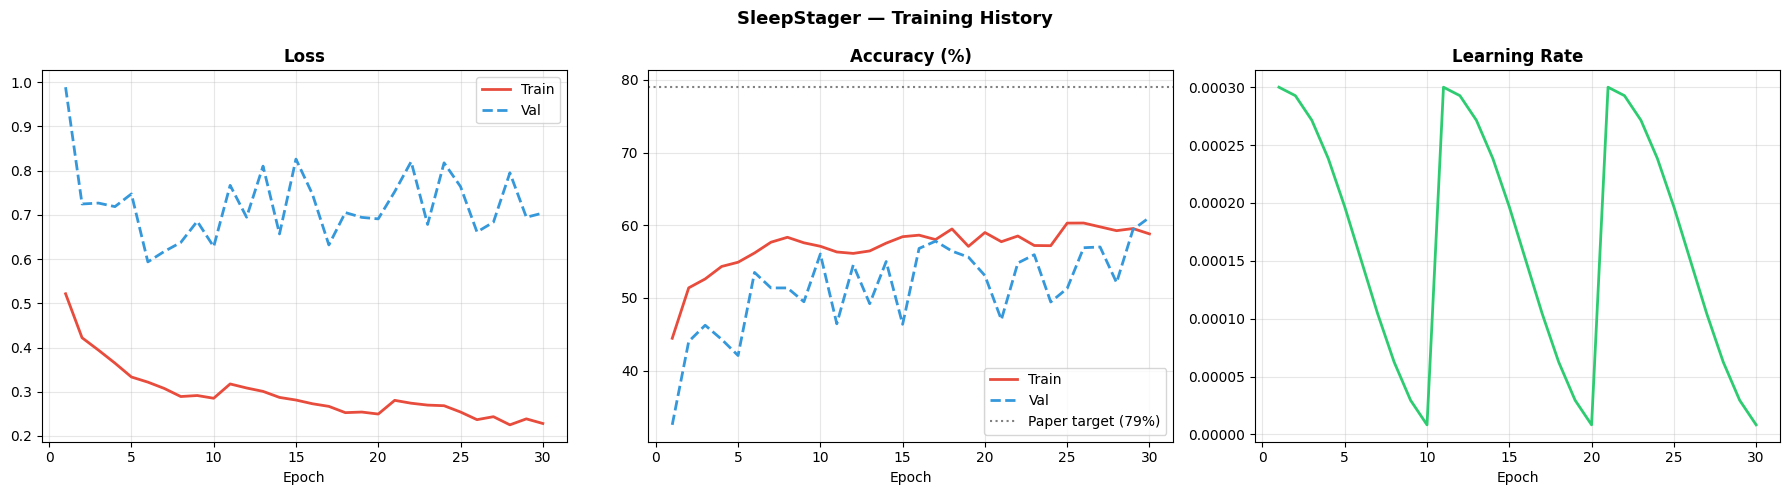

In [29]:
epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history['train_loss'], label='Train', color='#E74C3C', linewidth=2)
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='#3498DB', linewidth=2, linestyle='--')
axes[0].set_title('Loss', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, [a*100 for a in history['train_acc']], label='Train', color='#E74C3C', linewidth=2)
axes[1].plot(epochs_range, [a*100 for a in history['val_acc']],   label='Val',   color='#3498DB', linewidth=2, linestyle='--')
axes[1].axhline(79, color='gray', linestyle=':', linewidth=1.5, label='Paper target (79%)')
axes[1].set_title('Accuracy (%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history['lr'], color='#2ECC71', linewidth=2)
axes[2].set_title('Learning Rate', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].grid(True, alpha=0.3)

plt.suptitle('SleepStager — Training History', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves_v2.png', dpi=150)
plt.show()

---
## Step 22 — Test-Time Augmentation (TTA) Evaluation 

TTA runs inference multiple times with slight variations and averages the probability outputs.

In [30]:
# Load best checkpoint
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f'Loaded checkpoint from epoch {checkpoint["epoch"]}  (val_acc={checkpoint["val_acc"]*100:.2f}%)')


@torch.no_grad()
def predict_with_tta(model, loader, device, n_tta=5):
    """
    Test-Time Augmentation: run n_tta forward passes with slight noise,
    average the softmax probabilities.
    """
    all_probs_tta = []   # list of n_tta prediction arrays

    for tta_i in range(n_tta):
        probs_run = []
        for wav_batch, hrv_batch, _ in loader:
            wav_batch = wav_batch.to(device)
            hrv_batch = hrv_batch.to(device)

            if tta_i > 0:   # first pass is clean; rest have slight noise
                wav_batch = wav_batch + torch.randn_like(wav_batch) * 0.01

            logits = model(wav_batch, hrv_batch)
            probs  = torch.softmax(logits, dim=1)
            probs_run.append(probs.cpu().numpy())

        all_probs_tta.append(np.concatenate(probs_run, axis=0))

    # Average over TTA passes
    avg_probs = np.mean(all_probs_tta, axis=0)     # (N, num_classes)
    preds     = avg_probs.argmax(axis=1)
    return preds, avg_probs


print('Running Test-Time Augmentation (5 passes)...')
all_preds, all_probs = predict_with_tta(model, test_loader, device, n_tta=5)

# Collect true labels
all_true = y_test

test_acc = accuracy_score(all_true, all_preds)
print(f'\n=== Test Results (with TTA) ===')
print(f'Overall Accuracy : {test_acc*100:.2f}%')
print(f'Reference paper  : 79.00%')

print(f'\nClassification Report:')
print(classification_report(all_true, all_preds, target_names=CLASS_NAMES, digits=4))

Loaded checkpoint from epoch 30  (val_acc=61.07%)
Running Test-Time Augmentation (5 passes)...

=== Test Results (with TTA) ===
Overall Accuracy : 69.64%
Reference paper  : 79.00%

Classification Report:
               precision    recall  f1-score   support

         Wake     0.8889    0.5209    0.6569       215
Light (N1+N2)     0.7508    0.8872    0.8133       771
    Deep (N3)     0.0000    0.0000    0.0000        24
          REM     0.2407    0.2063    0.2222       189

     accuracy                         0.6964      1199
    macro avg     0.4701    0.4036    0.4231      1199
 weighted avg     0.6801    0.6964    0.6758      1199



---
## Step 23 — Confusion Matrix

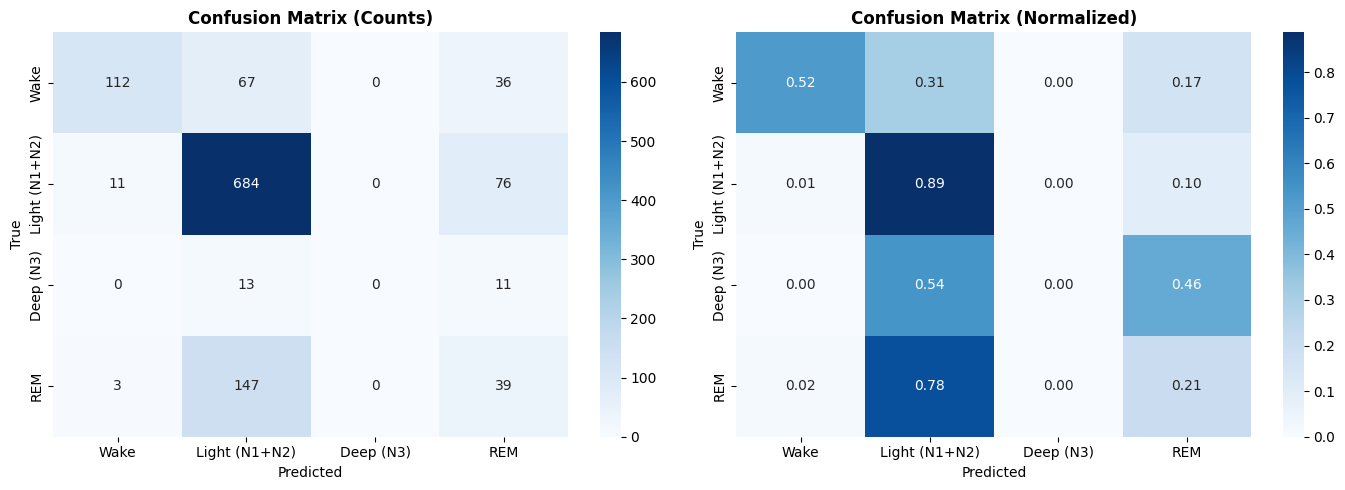

In [31]:
cm      = confusion_matrix(all_true, all_preds)
cm_norm = confusion_matrix(all_true, all_preds, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('confusion_matrix_v2.png', dpi=150)
plt.show()

---
## Step 24 — ROC Curves

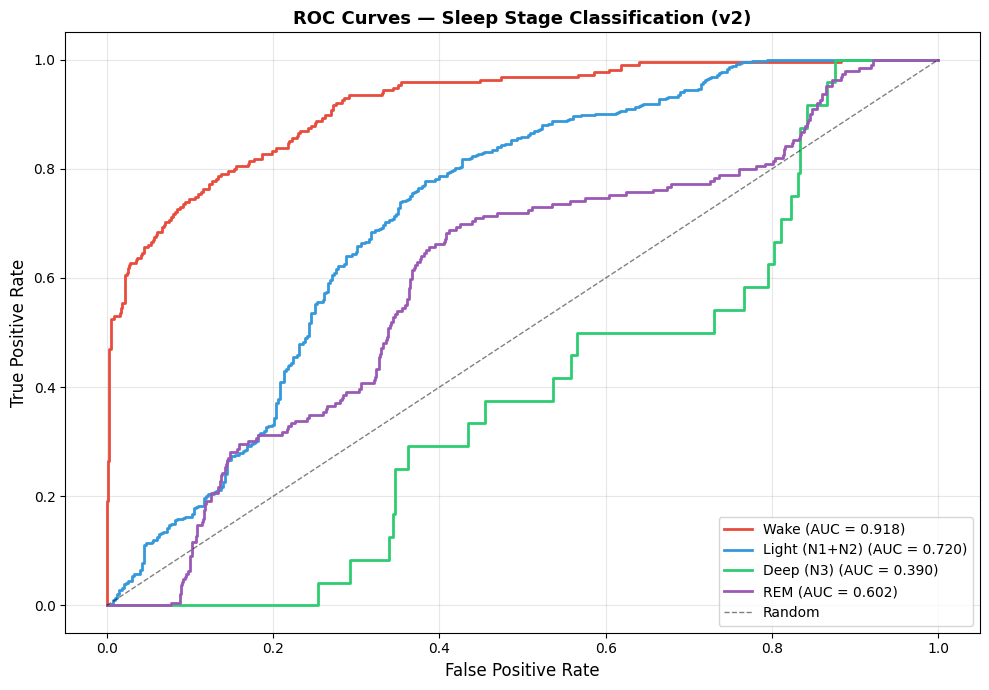

In [32]:
y_true_bin = label_binarize(all_true, classes=list(range(NUM_CLASSES)))
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']

plt.figure(figsize=(10, 7))
for i, (name, color) in enumerate(zip(CLASS_NAMES, colors)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    auc = roc_auc_score(y_true_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Sleep Stage Classification (v2)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves_v2.png', dpi=150)
plt.show()

---
## Step 25 — Per-Class Metrics

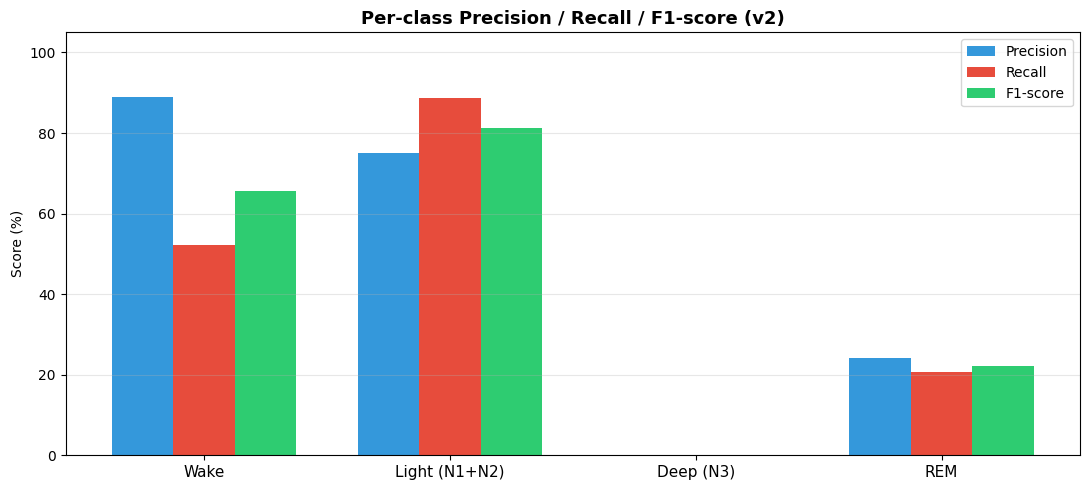

In [33]:
precision, recall, f1, support = precision_recall_fscore_support(
    all_true, all_preds, labels=list(range(NUM_CLASSES))
)

x = np.arange(NUM_CLASSES)
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, precision * 100, width, label='Precision', color='#3498DB')
ax.bar(x,         recall    * 100, width, label='Recall',    color='#E74C3C')
ax.bar(x + width, f1        * 100, width, label='F1-score',  color='#2ECC71')

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 105)
ax.set_title('Per-class Precision / Recall / F1-score (v2)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_metrics_v2.png', dpi=150)
plt.show()

---
## Step 26 — Final Summary

In [34]:
macro_f1  = f1.mean()
macro_auc = roc_auc_score(y_true_bin, all_probs, average='macro')

print('=' * 65)
print('           FINAL PERFORMANCE SUMMARY — SleepStager')
print('=' * 65)

summary_data = []
for i, name in enumerate(CLASS_NAMES):
    summary_data.append({
        'Class':          name,
        'Precision (%)':  f'{precision[i]*100:.2f}',
        'Recall (%)':     f'{recall[i]*100:.2f}',
        'F1-score (%)':   f'{f1[i]*100:.2f}',
        'Support':        support[i],
    })

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))
print('-' * 65)
print(f'Overall Accuracy : {test_acc*100:.2f}%')
print(f'Macro F1-score   : {macro_f1*100:.2f}%')
print(f'Macro AUC        : {macro_auc:.4f}')
print('=' * 65)
print(f'Reference paper  : ~79% accuracy (Zhang et al. 2023)')
print('=' * 65)

           FINAL PERFORMANCE SUMMARY — SleepStager
        Class Precision (%) Recall (%) F1-score (%)  Support
         Wake         88.89      52.09        65.69      215
Light (N1+N2)         75.08      88.72        81.33      771
    Deep (N3)          0.00       0.00         0.00       24
          REM         24.07      20.63        22.22      189
-----------------------------------------------------------------
Overall Accuracy : 69.64%
Macro F1-score   : 42.31%
Macro AUC        : 0.6576
Reference paper  : ~79% accuracy (Zhang et al. 2023)


---
## Step 27 — Hypnogram Comparison

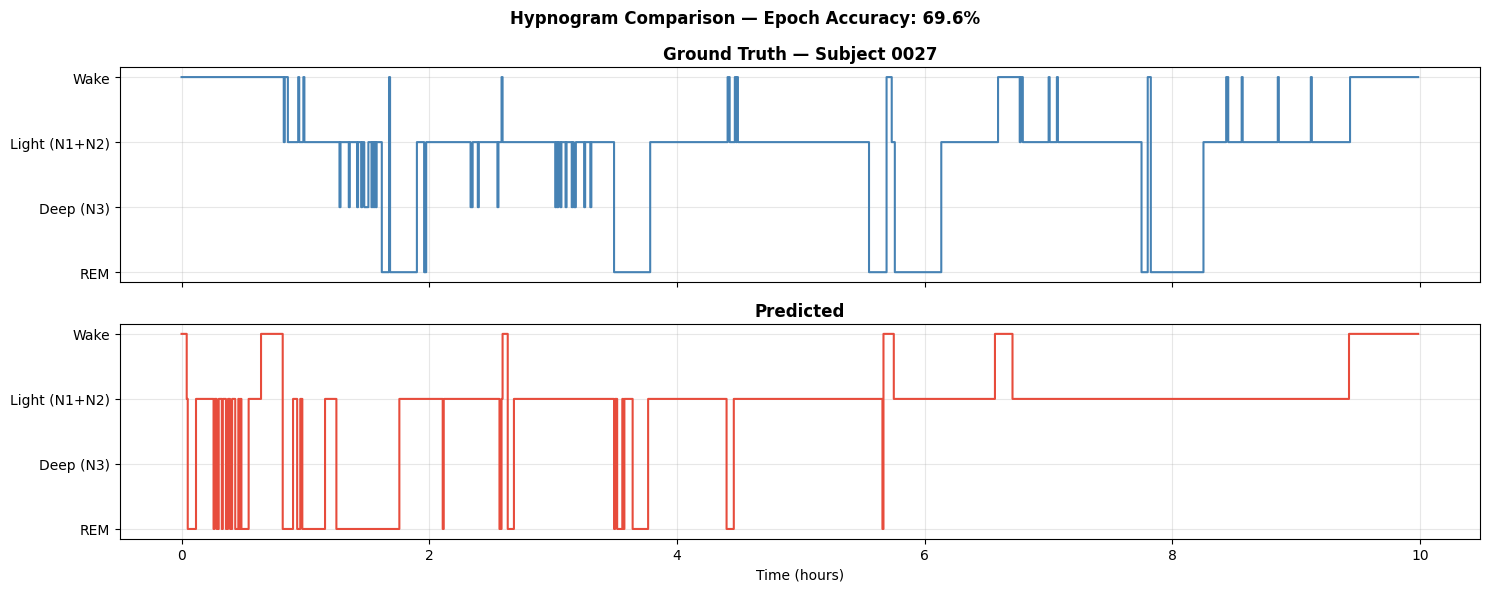

In [35]:
# Compare predicted vs true hypnogram for one test subject
first_test_sid = list(test_subjects)[0]
subj_mask = (test_sids == first_test_sid)

subj_true  = all_true[subj_mask]
subj_preds = all_preds[subj_mask]
time_h     = np.arange(len(subj_true)) * 30 / 3600

fig, axes = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

axes[0].step(time_h, subj_true,  where='post', color='steelblue',  linewidth=1.5)
axes[0].set_yticks([0, 1, 2, 3])
axes[0].set_yticklabels(CLASS_NAMES)
axes[0].set_title(f'Ground Truth — Subject {first_test_sid}', fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3)

axes[1].step(time_h, subj_preds, where='post', color='#E74C3C', linewidth=1.5)
axes[1].set_yticks([0, 1, 2, 3])
axes[1].set_yticklabels(CLASS_NAMES)
axes[1].set_title('Predicted', fontweight='bold')
axes[1].set_xlabel('Time (hours)')
axes[1].invert_yaxis()
axes[1].grid(True, alpha=0.3)

subj_acc = (subj_true == subj_preds).mean() * 100
plt.suptitle(f'Hypnogram Comparison — Epoch Accuracy: {subj_acc:.1f}%',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('hypnogram_comparison_v2.png', dpi=150)
plt.show()